In [63]:
# ============================================================
# SECTION 1 : DATA COLLECTION — Kafka Producer
# Simulation d'événements GPS transport en temps réel
# ============================================================

import json
import time
import random
import uuid
from datetime import datetime
from kafka import KafkaProducer

# Configuration
KAFKA_BROKER = 'localhost:9092'
TOPIC_NAME   = 'transport_events'

# Villes marocaines avec coordonnées GPS
VILLES = {
    'Casablanca' : (33.5731, -7.5898),
    'Rabat'      : (34.0209, -6.8416),
    'Marrakech'  : (31.6295, -7.9811),
    'Fes'        : (34.0331, -5.0003),
    'Tanger'     : (35.7595, -5.8340),
    'Agadir'     : (30.4278, -9.5981),
    'Meknes'     : (33.8935, -5.5473),
    'Oujda'      : (34.6814, -1.9086),
}

TYPES_VEHICULES  = ['Camion', 'Fourgon', 'Moto', 'Voiture']
STATUTS          = ['En_route', 'Livré', 'En_attente', 'Retardé']
CAUSES_RETARD    = ['Trafic', 'Météo', 'Panne', 'Accident', None]

print(" Configuration chargée")
print(f"   Broker  : {KAFKA_BROKER}")
print(f"   Topic   : {TOPIC_NAME}")
print(f"   Villes  : {len(VILLES)}")

 Configuration chargée
   Broker  : localhost:9092
   Topic   : transport_events
   Villes  : 8


In [64]:
# ============================================================
# Générateur d'événements de transport simulés
# ============================================================

def generer_evenement():
    """Génère un événement transport aléatoire réaliste"""

    ville_depart  = random.choice(list(VILLES.keys()))
    ville_arrivee = random.choice([v for v in VILLES.keys() if v != ville_depart])

    lat_dep, lon_dep = VILLES[ville_depart]
    lat_arr, lon_arr = VILLES[ville_arrivee]

    # Position actuelle (entre départ et arrivée)
    progression = random.uniform(0, 1)
    lat_actuel  = lat_dep + (lat_arr - lat_dep) * progression
    lon_actuel  = lon_dep + (lon_arr - lon_dep) * progression

    # Calcul distance approximative (km)
    distance_km = round(
        ((lat_arr - lat_dep)**2 + (lon_arr - lon_dep)**2)**0.5 * 111, 2
    )

    # Statut et retard
    statut        = random.choices(
        STATUTS,
        weights=[50, 25, 15, 10]
    )[0]
    est_retarde   = 1 if statut == 'Retardé' else random.choice([0, 0, 0, 1])
    retard_min    = random.randint(15, 180) if est_retarde else 0
    cause_retard  = random.choice(CAUSES_RETARD[:-1]) if est_retarde else None

    evenement = {
        'event_id'        : str(uuid.uuid4()),
        'timestamp'       : datetime.now().isoformat(),
        'vehicule_id'     : f"VH-{random.randint(1000, 9999)}",
        'type_vehicule'   : random.choice(TYPES_VEHICULES),
        'chauffeur_id'    : f"DR-{random.randint(100, 999)}",
        'ville_depart'    : ville_depart,
        'ville_arrivee'   : ville_arrivee,
        'latitude'        : round(lat_actuel, 6),
        'longitude'       : round(lon_actuel, 6),
        'vitesse_kmh'     : round(random.uniform(0, 130), 1),
        'distance_km'     : distance_km,
        'progression_pct' : round(progression * 100, 1),
        'statut'          : statut,
        'est_retarde'     : est_retarde,
        'retard_minutes'  : retard_min,
        'cause_retard'    : cause_retard,
        'temperature_c'   : round(random.uniform(5, 45), 1),
        'trafic_niveau'   : random.choice(['Faible', 'Moyen', 'Élevé']),
        'colis_nbr'       : random.randint(1, 50),
        'poids_kg'        : round(random.uniform(10, 5000), 1),
    }

    return evenement

# Test du générateur
evt = generer_evenement()
print(" Exemple d'événement généré :")
print(json.dumps(evt, indent=2, ensure_ascii=False))

 Exemple d'événement généré :
{
  "event_id": "a3130a9e-1de4-47be-b5d9-f86d4f5177d9",
  "timestamp": "2026-03-17T17:31:30.880975",
  "vehicule_id": "VH-6991",
  "type_vehicule": "Camion",
  "chauffeur_id": "DR-158",
  "ville_depart": "Rabat",
  "ville_arrivee": "Tanger",
  "latitude": 35.050261,
  "longitude": -6.245037,
  "vitesse_kmh": 62.8,
  "distance_km": 223.05,
  "progression_pct": 59.2,
  "statut": "En_attente",
  "est_retarde": 0,
  "retard_minutes": 0,
  "cause_retard": null,
  "temperature_c": 38.7,
  "trafic_niveau": "Élevé",
  "colis_nbr": 18,
  "poids_kg": 947.0
}


In [65]:
# ============================================================
# Kafka Producer — Envoi des événements vers le topic
# ============================================================

def creer_producer():
    """Crée et retourne un KafkaProducer"""
    producer = KafkaProducer(
        bootstrap_servers=[KAFKA_BROKER],
        value_serializer=lambda v: json.dumps(v, ensure_ascii=False).encode('utf-8'),
        key_serializer=lambda k: k.encode('utf-8'),
        acks='all',
        retries=3,
    )
    return producer

def envoyer_evenements(nb_evenements=100, delai_sec=0.1):
    """Envoie nb_evenements événements vers Kafka"""

    producer  = creer_producer()
    envoyes   = 0
    retardes  = 0

    print(f"🚀 Envoi de {nb_evenements} événements vers '{TOPIC_NAME}'...")
    print("-" * 55)

    for i in range(nb_evenements):
        evt = generer_evenement()

        # Clé = vehicule_id pour garantir l'ordre par véhicule
        producer.send(
            topic=TOPIC_NAME,
            key=evt['vehicule_id'],
            value=evt
        )

        envoyes  += 1
        retardes += evt['est_retarde']

        if (i + 1) % 20 == 0:
            print(f"   [{i+1:3d}/{nb_evenements}] envoyés | "
                  f"retardés: {retardes} "
                  f"({retardes/(i+1)*100:.1f}%)")

        time.sleep(delai_sec)

    producer.flush()
    producer.close()

    print("-" * 55)
    print(f" Terminé !")
    print(f"   Total envoyés  : {envoyes}")
    print(f"   Total retardés : {retardes} ({retardes/envoyes*100:.1f}%)")
    print(f"   Topic          : {TOPIC_NAME}")

# Lancer l'envoi
envoyer_evenements(nb_evenements=500, delai_sec=0.05)

🚀 Envoi de 500 événements vers 'transport_events'...
-------------------------------------------------------
   [ 20/500] envoyés | retardés: 9 (45.0%)
   [ 40/500] envoyés | retardés: 17 (42.5%)
   [ 60/500] envoyés | retardés: 26 (43.3%)
   [ 80/500] envoyés | retardés: 29 (36.2%)
   [100/500] envoyés | retardés: 34 (34.0%)
   [120/500] envoyés | retardés: 39 (32.5%)
   [140/500] envoyés | retardés: 47 (33.6%)
   [160/500] envoyés | retardés: 58 (36.2%)
   [180/500] envoyés | retardés: 66 (36.7%)
   [200/500] envoyés | retardés: 76 (38.0%)
   [220/500] envoyés | retardés: 85 (38.6%)
   [240/500] envoyés | retardés: 92 (38.3%)
   [260/500] envoyés | retardés: 97 (37.3%)
   [280/500] envoyés | retardés: 100 (35.7%)
   [300/500] envoyés | retardés: 105 (35.0%)
   [320/500] envoyés | retardés: 112 (35.0%)
   [340/500] envoyés | retardés: 117 (34.4%)
   [360/500] envoyés | retardés: 121 (33.6%)
   [380/500] envoyés | retardés: 124 (32.6%)
   [400/500] envoyés | retardés: 130 (32.5%)
   [4

In [66]:
# ============================================================
# Sauvegarde raw data en JSON → data/raw/
# ============================================================

import os
import pandas as pd

def collecter_et_sauvegarder(nb_evenements=500):
    """Génère les événements et les sauvegarde en Parquet"""

    print(f" Génération de {nb_evenements} événements...")

    evenements = [generer_evenement() for _ in range(nb_evenements)]
    df         = pd.DataFrame(evenements)

    # Créer le dossier si inexistant
    os.makedirs('data/raw', exist_ok=True)

    # Sauvegarde JSON
    json_path = 'data/raw/transport_events_raw.json'
    df.to_json(json_path, orient='records', indent=2, force_ascii=False)

    # Sauvegarde Parquet
    parquet_path = 'data/raw/transport_events_raw.parquet'
    df.to_parquet(parquet_path, index=False)

    print(f" Données sauvegardées !")
    print(f"   JSON    : {json_path}")
    print(f"   Parquet : {parquet_path}")
    print(f"\n Aperçu du dataset :")
    print(f"   Lignes   : {df.shape[0]}")
    print(f"   Colonnes : {df.shape[1]}")
    print(f"\n{df.head(3).to_string()}")

    return df

# Collecter et sauvegarder
df_raw = collecter_et_sauvegarder(500)



 Génération de 500 événements...
 Données sauvegardées !
   JSON    : data/raw/transport_events_raw.json
   Parquet : data/raw/transport_events_raw.parquet

 Aperçu du dataset :
   Lignes   : 500
   Colonnes : 20

                               event_id                   timestamp vehicule_id type_vehicule chauffeur_id ville_depart ville_arrivee   latitude  longitude  vitesse_kmh  distance_km  progression_pct      statut  est_retarde  retard_minutes cause_retard  temperature_c trafic_niveau  colis_nbr  poids_kg
0  0ff799fd-969f-46d4-877e-3f3cf7e676d2  2026-03-17T17:32:01.770699     VH-3628       Voiture       DR-503       Agadir    Casablanca  32.478804  -8.288517         88.5       414.23             65.2  En_attente            0               0         None           36.8         Moyen         19    1465.9
1  22b39d5f-8915-4a2e-a1eb-1c1efafdf84d  2026-03-17T17:32:01.770699     VH-5377          Moto       DR-515       Meknes         Rabat  33.939290  -6.012496        114.7       144.3

In [67]:
# ============================================================
# Configuration Hadoop/Spark pour Windows
# ============================================================
import os
import sys

# Configurer HADOOP_HOME
os.environ['HADOOP_HOME'] = r'C:\hadoop'
os.environ['PATH'] = os.environ['PATH'] + r';C:\hadoop\bin'

# Configurer JAVA_HOME si nécessaire
# os.environ['JAVA_HOME'] = r'C:\Program Files\Java\jdk-17'

print(" Variables d'environnement configurées")
print(f"   HADOOP_HOME : {os.environ['HADOOP_HOME']}")

 Variables d'environnement configurées
   HADOOP_HOME : C:\hadoop


In [68]:
# ============================================================
# SECTION 2 : DATA CLEANING — PySpark
# Nettoyage : nulls, doublons, outliers, types
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import warnings
warnings.filterwarnings('ignore')

# Créer la SparkSession
spark = SparkSession.builder \
    .appName("Transport_DataCleaning") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.ui.showConsoleProgress", "false") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print(" SparkSession créée !")
print(f"   Version Spark : {spark.version}")
print(f"   Master        : {spark.sparkContext.master}")

 SparkSession créée !
   Version Spark : 3.5.0
   Master        : local[*]


In [69]:
# ============================================================
# Chargement des données brutes depuis Parquet
# ============================================================

df_spark = spark.read.parquet("data/raw/transport_events_raw.parquet")

print(" Données chargées !")
print(f"   Lignes   : {df_spark.count()}")
print(f"   Colonnes : {len(df_spark.columns)}")
print("\n Schéma :")
df_spark.printSchema()
print("\n Aperçu (3 lignes) :")
df_spark.show(3, truncate=False)

 Données chargées !
   Lignes   : 500
   Colonnes : 20

 Schéma :
root
 |-- event_id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- vehicule_id: string (nullable = true)
 |-- type_vehicule: string (nullable = true)
 |-- chauffeur_id: string (nullable = true)
 |-- ville_depart: string (nullable = true)
 |-- ville_arrivee: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- vitesse_kmh: double (nullable = true)
 |-- distance_km: double (nullable = true)
 |-- progression_pct: double (nullable = true)
 |-- statut: string (nullable = true)
 |-- est_retarde: long (nullable = true)
 |-- retard_minutes: long (nullable = true)
 |-- cause_retard: string (nullable = true)
 |-- temperature_c: double (nullable = true)
 |-- trafic_niveau: string (nullable = true)
 |-- colis_nbr: long (nullable = true)
 |-- poids_kg: double (nullable = true)


 Aperçu (3 lignes) :
+------------------------------------+----------------

In [70]:
# ============================================================
# Audit qualité : valeurs nulles, doublons, statistiques
# ============================================================

print("=" * 55)
print("        RAPPORT QUALITÉ DES DONNÉES")
print("=" * 55)

total = df_spark.count()

# 1. Valeurs nulles par colonne
print("\n 1. VALEURS NULLES PAR COLONNE :")
print("-" * 40)
for col in df_spark.columns:
    nulls = df_spark.filter(F.col(col).isNull()).count()
    pct   = nulls / total * 100
    flag  = " !!!" if nulls > 0 else " bon"
    print(f"   {col:<25} : {nulls:4d} ({pct:5.1f}%){flag}")

# 2. Doublons
doublons = total - df_spark.dropDuplicates(['event_id']).count()
print(f"\n 2. DOUBLONS : {doublons}")

# 3. Outliers vitesse
print("\n 3. OUTLIERS VITESSE (kmh) :")
df_spark.select(
    F.min('vitesse_kmh').alias('min'),
    F.max('vitesse_kmh').alias('max'),
    F.mean('vitesse_kmh').alias('moyenne'),
    F.stddev('vitesse_kmh').alias('std')
).show()

vitesse_invalide = df_spark.filter(
    (F.col('vitesse_kmh') < 0) | (F.col('vitesse_kmh') > 130)
).count()
print(f"   Vitesses invalides (<0 ou >130) : {vitesse_invalide}")

# 4. Coordonnées GPS invalides (Maroc)
print("\n 4. COORDONNÉES GPS INVALIDES :")
gps_invalide = df_spark.filter(
    (F.col('latitude')  < 27.0) | (F.col('latitude')  > 36.0) |
    (F.col('longitude') < -14.0) | (F.col('longitude') > 0.0)
).count()
print(f"   Coordonnées hors Maroc : {gps_invalide}")

# 5. Distribution des statuts
print("\n 5. DISTRIBUTION STATUTS :")
df_spark.groupBy('statut').count() \
    .orderBy(F.desc('count')).show()

print("=" * 55)

        RAPPORT QUALITÉ DES DONNÉES

 1. VALEURS NULLES PAR COLONNE :
----------------------------------------
   event_id                  :    0 (  0.0%) bon
   timestamp                 :    0 (  0.0%) bon
   vehicule_id               :    0 (  0.0%) bon
   type_vehicule             :    0 (  0.0%) bon
   chauffeur_id              :    0 (  0.0%) bon
   ville_depart              :    0 (  0.0%) bon
   ville_arrivee             :    0 (  0.0%) bon
   latitude                  :    0 (  0.0%) bon
   longitude                 :    0 (  0.0%) bon
   vitesse_kmh               :    0 (  0.0%) bon
   distance_km               :    0 (  0.0%) bon
   progression_pct           :    0 (  0.0%) bon
   statut                    :    0 (  0.0%) bon
   est_retarde               :    0 (  0.0%) bon
   retard_minutes            :    0 (  0.0%) bon
   cause_retard              :  334 ( 66.8%) !!!
   temperature_c             :    0 (  0.0%) bon
   trafic_niveau             :    0 (  0.0%) bon
   coli

In [71]:
# ============================================================
# Nettoyage effectif des données
# ============================================================

print(" Nettoyage en cours...")
print("-" * 45)

df_clean = df_spark

# Étape 1 — Supprimer les doublons
avant = df_clean.count()
df_clean = df_clean.dropDuplicates(['event_id'])
apres = df_clean.count()
print(f" Doublons supprimés     : {avant - apres} lignes")

# Étape 2 — Corriger les valeurs nulles
df_clean = df_clean \
    .fillna({'cause_retard'   : 'Aucune'}) \
    .fillna({'vitesse_kmh'    : 0.0}) \
    .fillna({'retard_minutes' : 0}) \
    .fillna({'trafic_niveau'  : 'Moyen'})
print(" Valeurs nulles comblées")

# Étape 3 — Filtrer les outliers vitesse
avant = df_clean.count()
df_clean = df_clean.filter(
    (F.col('vitesse_kmh') >= 0) &
    (F.col('vitesse_kmh') <= 130)
)
print(f" Outliers vitesse filtrés: {avant - df_clean.count()} lignes")

# Étape 4 — Filtrer GPS invalides
avant = df_clean.count()
df_clean = df_clean.filter(
    (F.col('latitude')  >= 27.0) & (F.col('latitude')  <= 36.0) &
    (F.col('longitude') >= -14.0) & (F.col('longitude') <= 0.0)
)
print(f" GPS invalides filtrés  : {avant - df_clean.count()} lignes")

# Étape 5 — Corriger les types
df_clean = df_clean \
    .withColumn('timestamp',
        F.to_timestamp(F.col('timestamp'))) \
    .withColumn('est_retarde',
        F.col('est_retarde').cast(IntegerType())) \
    .withColumn('vitesse_kmh',
        F.col('vitesse_kmh').cast(DoubleType())) \
    .withColumn('distance_km',
        F.col('distance_km').cast(DoubleType()))
print(" Types corrigés")

# Étape 6 — Standardiser les colonnes texte
df_clean = df_clean \
    .withColumn('statut',
        F.upper(F.trim(F.col('statut')))) \
    .withColumn('type_vehicule',
        F.upper(F.trim(F.col('type_vehicule')))) \
    .withColumn('trafic_niveau',
        F.upper(F.trim(F.col('trafic_niveau'))))
print(" Textes standardisés")

# Résumé
print("-" * 45)
print(f" Lignes avant nettoyage : {df_spark.count()}")
print(f" Lignes après nettoyage : {df_clean.count()}")
print(f" Lignes supprimées      : {df_spark.count() - df_clean.count()}")

 Nettoyage en cours...
---------------------------------------------
 Doublons supprimés     : 0 lignes
 Valeurs nulles comblées
 Outliers vitesse filtrés: 0 lignes
 GPS invalides filtrés  : 0 lignes
 Types corrigés
 Textes standardisés
---------------------------------------------
 Lignes avant nettoyage : 500
 Lignes après nettoyage : 500
 Lignes supprimées      : 0


In [72]:
# ============================================================
# Sauvegarde données nettoyées → data/cleaned/
# ============================================================

import os
os.makedirs('data/cleaned', exist_ok=True)

# Sauvegarde Parquet partitionné par statut
df_clean.write \
    .mode('overwrite') \
    .partitionBy('statut') \
    .parquet('data/cleaned/transport_events_cleaned.parquet')

# Sauvegarde CSV pour vérification visuelle
df_clean.coalesce(1).write \
    .mode('overwrite') \
    .option('header', 'true') \
    .csv('data/cleaned/transport_events_cleaned_csv')

print(" Données nettoyées sauvegardées !")
print("   Parquet : data/cleaned/transport_events_cleaned.parquet")
print("   CSV     : data/cleaned/transport_events_cleaned_csv/")

# Vérification finale
print(f"\n Dataset final propre :")
print(f"   Lignes   : {df_clean.count()}")
print(f"   Colonnes : {len(df_clean.columns)}")
df_clean.show(5, truncate=True)


 Données nettoyées sauvegardées !
   Parquet : data/cleaned/transport_events_cleaned.parquet
   CSV     : data/cleaned/transport_events_cleaned_csv/

 Dataset final propre :
   Lignes   : 500
   Colonnes : 20
+--------------------+--------------------+-----------+-------------+------------+------------+-------------+---------+---------+-----------+-----------+---------------+--------+-----------+--------------+------------+-------------+-------------+---------+--------+
|            event_id|           timestamp|vehicule_id|type_vehicule|chauffeur_id|ville_depart|ville_arrivee| latitude|longitude|vitesse_kmh|distance_km|progression_pct|  statut|est_retarde|retard_minutes|cause_retard|temperature_c|trafic_niveau|colis_nbr|poids_kg|
+--------------------+--------------------+-----------+-------------+------------+------------+-------------+---------+---------+-----------+-----------+---------------+--------+-----------+--------------+------------+-------------+-------------+---------+---

In [73]:
# ============================================================
# SECTION 3 : DATA TRANSFORMATION
# Normalisation, encodage, nouvelles variables temporelles
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import MinMaxScaler, VectorAssembler, StringIndexer
import pandas as pd
import numpy as np

# Charger données nettoyées
df_trans = spark.read.parquet("data/cleaned/transport_events_cleaned.parquet")

print("Données nettoyées chargées !")
print(f"   Lignes   : {df_trans.count()}")
print(f"   Colonnes : {len(df_trans.columns)}")
df_trans.show(3, truncate=True)

Données nettoyées chargées !
   Lignes   : 500
   Colonnes : 20
+--------------------+--------------------+-----------+-------------+------------+------------+-------------+---------+---------+-----------+-----------+---------------+-----------+--------------+------------+-------------+-------------+---------+--------+--------+
|            event_id|           timestamp|vehicule_id|type_vehicule|chauffeur_id|ville_depart|ville_arrivee| latitude|longitude|vitesse_kmh|distance_km|progression_pct|est_retarde|retard_minutes|cause_retard|temperature_c|trafic_niveau|colis_nbr|poids_kg|  statut|
+--------------------+--------------------+-----------+-------------+------------+------------+-------------+---------+---------+-----------+-----------+---------------+-----------+--------------+------------+-------------+-------------+---------+--------+--------+
|041d0529-b285-44d...|2026-03-17 17:32:...|    VH-3343|       CAMION|      DR-478|      Meknes|        Oujda|34.611606|-2.230923|      129

In [74]:
# ============================================================
# Transformation 1 : Variables temporelles depuis timestamp
# ============================================================

df_trans = df_trans \
    .withColumn('heure',
        F.hour(F.col('timestamp'))) \
    .withColumn('jour_semaine',
        F.dayofweek(F.col('timestamp'))) \
    .withColumn('mois',
        F.month(F.col('timestamp'))) \
    .withColumn('est_weekend',
        F.when(F.dayofweek(F.col('timestamp')).isin([1, 7]), 1).otherwise(0)) \
    .withColumn('est_heure_pointe',
        F.when(
            (F.hour(F.col('timestamp')).between(7, 9)) |
            (F.hour(F.col('timestamp')).between(17, 19)),
            1).otherwise(0)) \
    .withColumn('periode_journee',
        F.when(F.hour(F.col('timestamp')).between(6, 11),  'MATIN')
         .when(F.hour(F.col('timestamp')).between(12, 17), 'APRES_MIDI')
         .when(F.hour(F.col('timestamp')).between(18, 21), 'SOIR')
         .otherwise('NUIT'))

print(" Variables temporelles extraites :")
df_trans.select(
    'timestamp', 'heure', 'jour_semaine',
    'est_weekend', 'est_heure_pointe', 'periode_journee'
).show(5, truncate=False)

 Variables temporelles extraites :
+--------------------------+-----+------------+-----------+----------------+---------------+
|timestamp                 |heure|jour_semaine|est_weekend|est_heure_pointe|periode_journee|
+--------------------------+-----+------------+-----------+----------------+---------------+
|2026-03-17 17:32:01.775552|17   |3           |0          |1               |APRES_MIDI     |
|2026-03-17 17:32:01.775552|17   |3           |0          |1               |APRES_MIDI     |
|2026-03-17 17:32:01.775552|17   |3           |0          |1               |APRES_MIDI     |
|2026-03-17 17:32:01.775552|17   |3           |0          |1               |APRES_MIDI     |
|2026-03-17 17:32:01.775552|17   |3           |0          |1               |APRES_MIDI     |
+--------------------------+-----+------------+-----------+----------------+---------------+
only showing top 5 rows



In [75]:
# ============================================================
# Transformation 2 : Encodage Label + One-Hot
# ============================================================

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Colonnes catégorielles à encoder
cols_categoriques = [
    'type_vehicule',
    'trafic_niveau',
    'periode_journee',
    'cause_retard'
]

# StringIndexer pour chaque colonne
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_idx",
        handleInvalid='keep'
    )
    for col in cols_categoriques
]

# Appliquer les indexers
pipeline_encoding = Pipeline(stages=indexers)
df_trans = pipeline_encoding.fit(df_trans).transform(df_trans)

print(" Encodage Label appliqué :")
df_trans.select(
    'type_vehicule', 'type_vehicule_idx',
    'trafic_niveau', 'trafic_niveau_idx',
    'periode_journee', 'periode_journee_idx'
).show(5, truncate=False)

 Encodage Label appliqué :
+-------------+-----------------+-------------+-----------------+---------------+-------------------+
|type_vehicule|type_vehicule_idx|trafic_niveau|trafic_niveau_idx|periode_journee|periode_journee_idx|
+-------------+-----------------+-------------+-----------------+---------------+-------------------+
|CAMION       |0.0              |MOYEN        |1.0              |APRES_MIDI     |0.0                |
|VOITURE      |2.0              |FAIBLE       |2.0              |APRES_MIDI     |0.0                |
|FOURGON      |1.0              |FAIBLE       |2.0              |APRES_MIDI     |0.0                |
|CAMION       |0.0              |FAIBLE       |2.0              |APRES_MIDI     |0.0                |
|VOITURE      |2.0              |FAIBLE       |2.0              |APRES_MIDI     |0.0                |
+-------------+-----------------+-------------+-----------------+---------------+-------------------+
only showing top 5 rows



In [76]:
# ============================================================
# Transformation 3 : Normalisation MinMax (corrigée)
# ============================================================

from pyspark.ml.feature import MinMaxScaler, VectorAssembler
from pyspark.ml.functions import vector_to_array

# Colonnes numériques à normaliser
cols_numeriques = [
    'vitesse_kmh',
    'distance_km',
    'retard_minutes',
    'progression_pct',
    'temperature_c',
    'colis_nbr',
    'poids_kg'
]

# Normaliser chaque colonne individuellement
for col in cols_numeriques:
    assembler = VectorAssembler(
        inputCols=[col],
        outputCol=f"{col}_vec"
    )
    scaler = MinMaxScaler(
        inputCol=f"{col}_vec",
        outputCol=f"{col}_scaled"
    )
    df_trans = assembler.transform(df_trans)
    scaler_model = scaler.fit(df_trans)
    df_trans = scaler_model.transform(df_trans)

    # Extraire valeur depuis le vecteur — méthode compatible toutes versions
    df_trans = df_trans.withColumn(
        f"{col}_norm",
        vector_to_array(F.col(f"{col}_scaled")).getItem(0)
    ).drop(f"{col}_vec", f"{col}_scaled")

print("\n Normalisation MinMax appliquée !")
df_trans.select(
    'vitesse_kmh', 'vitesse_kmh_norm',
    'distance_km', 'distance_km_norm',
    'retard_minutes', 'retard_minutes_norm'
).show(5, truncate=False)


 Normalisation MinMax appliquée !
+-----------+-------------------+-----------+-------------------+--------------+-------------------+
|vitesse_kmh|vitesse_kmh_norm   |distance_km|distance_km_norm   |retard_minutes|retard_minutes_norm|
+-----------+-------------------+-----------+-------------------+--------------+-------------------+
|129.8      |1.0                |413.26     |0.38410973311713925|39            |0.22033898305084745|
|76.6       |0.5875968992248062 |413.26     |0.38410973311713925|0             |0.0                |
|54.1       |0.4131782945736434 |212.81     |0.16450107366668126|0             |0.0                |
|94.8       |0.7286821705426356 |96.79      |0.03739208554274947|0             |0.0                |
|4.4        |0.02790697674418605|648.55     |0.6418883386651474 |0             |0.0                |
+-----------+-------------------+-----------+-------------------+--------------+-------------------+
only showing top 5 rows



In [77]:
# ============================================================
# Transformation 4 : Distance Haversine (GPS réelle)
# ============================================================

# UDF Haversine pour distance GPS précise
def haversine_udf(lat1, lon1, lat2, lon2):
    """Calcule la distance réelle entre 2 points GPS en km"""
    if None in [lat1, lon1, lat2, lon2]:
        return 0.0
    R    = 6371.0
    lat1 = float(lat1) * 3.14159 / 180
    lat2 = float(lat2) * 3.14159 / 180
    dlat = lat2 - lat1
    dlon = (float(lon2) - float(lon1)) * 3.14159 / 180
    a    = (dlat/2)**2 + \
           (dlon/2)**2 * \
           (1 - (dlat/2)**2) * \
           (1 - (dlat/2)**2)
    import math
    a    = math.sin(dlat/2)**2 + \
           math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c    = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return round(R * c, 2)

haversine = F.udf(haversine_udf, DoubleType())

# Coordonnées des villes
villes_coords = {
    'Casablanca' : (33.5731, -7.5898),
    'Rabat'      : (34.0209, -6.8416),
    'Marrakech'  : (31.6295, -7.9811),
    'Fes'        : (34.0331, -5.0003),
    'Tanger'     : (35.7595, -5.8340),
    'Agadir'     : (30.4278, -9.5981),
    'Meknes'     : (33.8935, -5.5473),
    'Oujda'      : (34.6814, -1.9086),
}

# Créer table de référence
villes_data = [(k, float(v[0]), float(v[1])) for k, v in villes_coords.items()]
df_villes   = spark.createDataFrame(villes_data, ['ville', 'lat', 'lon'])

# Join pour obtenir coordonnées départ et arrivée
df_trans = df_trans \
    .join(df_villes.withColumnRenamed('lat', 'lat_dep')
                   .withColumnRenamed('lon', 'lon_dep')
                   .withColumnRenamed('ville', 'v_dep'),
          df_trans.ville_depart == F.col('v_dep'), 'left') \
    .join(df_villes.withColumnRenamed('lat', 'lat_arr')
                   .withColumnRenamed('lon', 'lon_arr')
                   .withColumnRenamed('ville', 'v_arr'),
          df_trans.ville_arrivee == F.col('v_arr'), 'left') \
    .drop('v_dep', 'v_arr')

# Calculer distance Haversine
df_trans = df_trans.withColumn(
    'distance_reelle_km',
    haversine(
        F.col('lat_dep'), F.col('lon_dep'),
        F.col('lat_arr'), F.col('lon_arr')
    )
)

print(" Distance Haversine calculée !")
df_trans.select(
    'ville_depart', 'ville_arrivee',
    'distance_km', 'distance_reelle_km'
).show(8, truncate=False)

 Distance Haversine calculée !
+------------+-------------+-----------+------------------+
|ville_depart|ville_arrivee|distance_km|distance_reelle_km|
+------------+-------------+-----------+------------------+
|Fes         |Tanger       |212.81     |206.47            |
|Fes         |Agadir       |648.55     |589.56            |
|Agadir      |Oujda        |975.42     |861.59            |
|Rabat       |Casablanca   |96.79      |85.2              |
|Marrakech   |Fes          |425.04     |385.96            |
|Meknes      |Oujda        |413.26     |345.56            |
|Oujda       |Meknes       |413.26     |345.56            |
|Oujda       |Rabat        |552.45     |458.73            |
+------------+-------------+-----------+------------------+
only showing top 8 rows



In [78]:
# ============================================================
# Sauvegarde données transformées → data/processed/
# ============================================================

import os
os.makedirs('data/processed', exist_ok=True)

df_trans.write \
    .mode('overwrite') \
    .parquet('data/processed/transport_events_transformed.parquet')

print(" Données transformées sauvegardées !")
print(f"   Chemin   : data/processed/transport_events_transformed.parquet")
print(f"   Lignes   : {df_trans.count()}")
print(f"   Colonnes : {len(df_trans.columns)}")

# Résumé des nouvelles colonnes
nouvelles_cols = [
    'heure', 'jour_semaine', 'est_weekend', 'est_heure_pointe',
    'periode_journee', 'type_vehicule_idx', 'trafic_niveau_idx',
    'vitesse_kmh_norm', 'distance_km_norm', 'distance_reelle_km'
]
print(f"\n Nouvelles colonnes créées ({len(nouvelles_cols)}) :")
for col in nouvelles_cols:
    print(f" {col}")

 Données transformées sauvegardées !
   Chemin   : data/processed/transport_events_transformed.parquet
   Lignes   : 500
   Colonnes : 42

 Nouvelles colonnes créées (10) :
 heure
 jour_semaine
 est_weekend
 est_heure_pointe
 periode_journee
 type_vehicule_idx
 trafic_niveau_idx
 vitesse_kmh_norm
 distance_km_norm
 distance_reelle_km


In [79]:
# ============================================================
# SECTION 4 : DATA REDUCTION
# PCA + Sélection de features par corrélation et importance
# ============================================================

from pyspark.ml.feature import PCA, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.ml.stat import Correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger données transformées
df_reduc = spark.read.parquet(
    "data/processed/transport_events_transformed.parquet"
)

print(" Données transformées chargées !")
print(f"   Lignes   : {df_reduc.count()}")
print(f"   Colonnes : {len(df_reduc.columns)}")

 Données transformées chargées !
   Lignes   : 500
   Colonnes : 42


In [80]:
# ============================================================
# Sélection des colonnes numériques pour la réduction
# ============================================================

# Features numériques disponibles après transformation
features_numeriques = [
    'vitesse_kmh_norm',
    'distance_km_norm',
    'retard_minutes_norm',
    'progression_pct_norm',
    'temperature_c_norm',
    'colis_nbr_norm',
    'poids_kg_norm',
    'heure',
    'jour_semaine',
    'est_weekend',
    'est_heure_pointe',
    'type_vehicule_idx',
    'trafic_niveau_idx',
    'periode_journee_idx',
    'cause_retard_idx',
]

# Vérifier que toutes les colonnes existent
cols_disponibles = df_reduc.columns
features_ok = [f for f in features_numeriques if f in cols_disponibles]
features_manquantes = [f for f in features_numeriques if f not in cols_disponibles]

print(f" Features disponibles  : {len(features_ok)}")
if features_manquantes:
    print(f"!!!  Features manquantes  : {features_manquantes}")

# Assembler toutes les features en un seul vecteur
assembler = VectorAssembler(
    inputCols=features_ok,
    outputCol='features_vector',
    handleInvalid='skip'
)

df_assembled = assembler.transform(df_reduc)
print(f"\n Vecteur de features assemblé : {len(features_ok)} dimensions")
df_assembled.select('features_vector').show(3, truncate=True)

 Features disponibles  : 15

 Vecteur de features assemblé : 15 dimensions
+--------------------+
|     features_vector|
+--------------------+
|[0.41317829457364...|
|[0.02790697674418...|
|[0.24961240310077...|
+--------------------+
only showing top 3 rows



 Calcul de la matrice de corrélation...


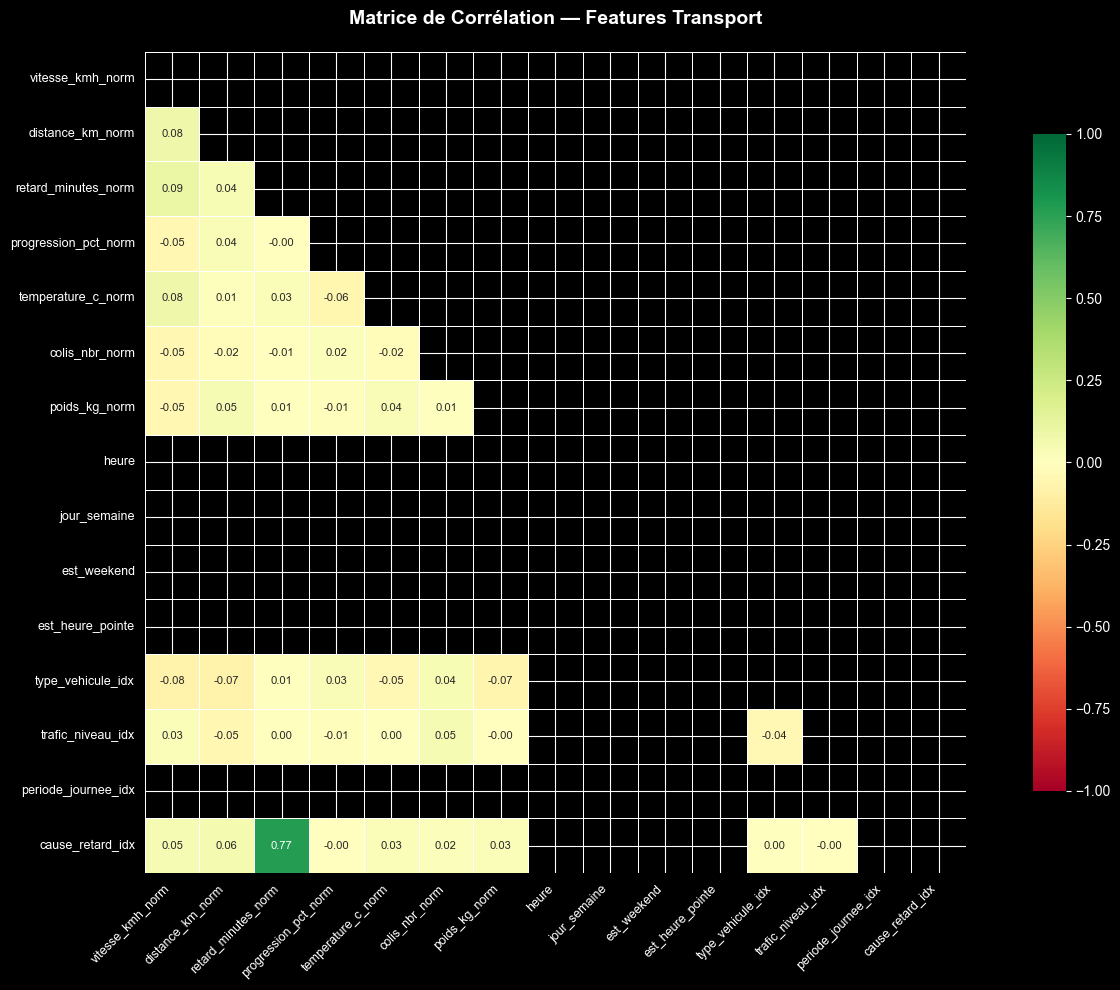

 Matrice de corrélation sauvegardée !


In [81]:
# ============================================================
# Analyse de corrélation entre les features
# ============================================================

# Calculer la matrice de corrélation Pearson
print(" Calcul de la matrice de corrélation...")
corr_matrix = Correlation.corr(
    df_assembled,
    'features_vector',
    method='pearson'
).head()[0]

# Convertir en numpy array
corr_array = corr_matrix.toArray()
corr_df    = pd.DataFrame(
    corr_array,
    index=features_ok,
    columns=features_ok
)

# Visualiser la heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_array, dtype=bool))
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
plt.title('Matrice de Corrélation — Features Transport',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

os.makedirs('outputs/reports', exist_ok=True)
plt.savefig('outputs/reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Matrice de corrélation sauvegardée !")

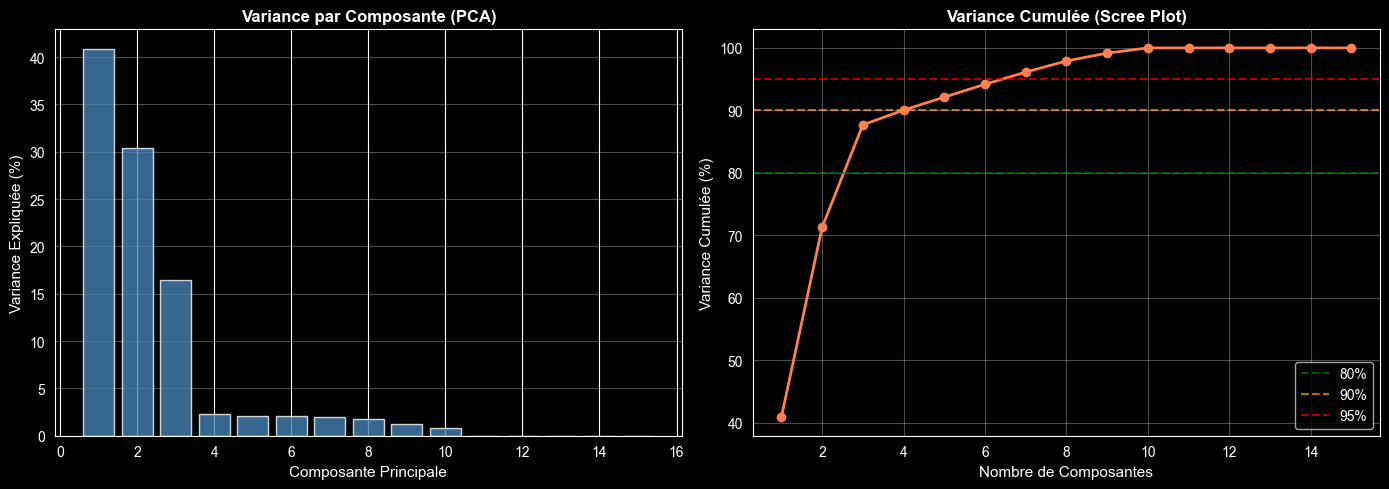

 Analyse PCA terminée !
   Composantes pour 80% variance : 3
   Composantes pour 90% variance : 4
   Composantes pour 95% variance : 7

   → On choisit 4 composantes (90% variance)


In [82]:
# ============================================================
# PCA — Réduction de dimensionnalité
# ============================================================

# Étape 1 : PCA avec toutes les composantes pour analyse
pca_full = PCA(
    k=len(features_ok),
    inputCol='features_vector',
    outputCol='pca_full_output'
)
pca_full_model = pca_full.fit(df_assembled)

# Variance expliquée par chaque composante
variance_expl  = pca_full_model.explainedVariance.toArray()
variance_cumul = np.cumsum(variance_expl)

# Visualiser la variance expliquée
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 — Variance par composante
axes[0].bar(
    range(1, len(variance_expl) + 1),
    variance_expl * 100,
    color='steelblue', alpha=0.8, edgecolor='white'
)
axes[0].set_xlabel('Composante Principale', fontsize=11)
axes[0].set_ylabel('Variance Expliquée (%)', fontsize=11)
axes[0].set_title('Variance par Composante (PCA)', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Graphe 2 — Variance cumulée
axes[1].plot(
    range(1, len(variance_cumul) + 1),
    variance_cumul * 100,
    'o-', color='coral', linewidth=2, markersize=6
)
axes[1].axhline(y=80, color='green',  linestyle='--', alpha=0.7, label='80%')
axes[1].axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%')
axes[1].axhline(y=95, color='red',    linestyle='--', alpha=0.7, label='95%')
axes[1].set_xlabel('Nombre de Composantes', fontsize=11)
axes[1].set_ylabel('Variance Cumulée (%)', fontsize=11)
axes[1].set_title('Variance Cumulée (Scree Plot)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/reports/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Déterminer le nombre optimal de composantes
n_comp_80 = np.argmax(variance_cumul >= 0.80) + 1
n_comp_90 = np.argmax(variance_cumul >= 0.90) + 1
n_comp_95 = np.argmax(variance_cumul >= 0.95) + 1

print(f" Analyse PCA terminée !")
print(f"   Composantes pour 80% variance : {n_comp_80}")
print(f"   Composantes pour 90% variance : {n_comp_90}")
print(f"   Composantes pour 95% variance : {n_comp_95}")
print(f"\n   → On choisit {n_comp_90} composantes (90% variance)")

 PCA finale appliquée !
   Dimensions initiales  : 15
   Dimensions après PCA  : 4
   Réduction             : 73.3%

 Top 10 features les plus importantes :
             feature  importance
    cause_retard_idx    0.983496
 retard_minutes_norm    0.179666
    vitesse_kmh_norm    0.013456
    distance_km_norm    0.010348
  temperature_c_norm    0.006534
       poids_kg_norm    0.006384
   type_vehicule_idx    0.006233
   trafic_niveau_idx    0.005155
      colis_nbr_norm    0.004230
progression_pct_norm    0.000201


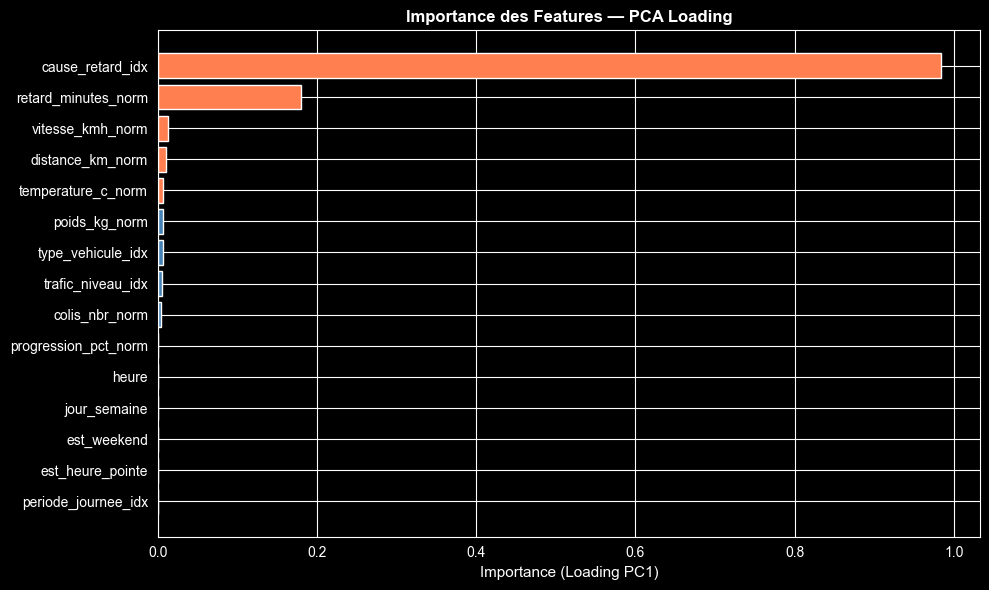

In [83]:
# ============================================================
# PCA finale + Sélection des meilleures features
# ============================================================

# Appliquer PCA avec le nombre optimal de composantes
N_COMPOSANTES = n_comp_90

pca_final = PCA(
    k=N_COMPOSANTES,
    inputCol='features_vector',
    outputCol='pca_features'
)
pca_model  = pca_final.fit(df_assembled)
df_pca     = pca_model.transform(df_assembled)

# Extraire les composantes PCA comme colonnes séparées
df_pca = df_pca.withColumn(
    'pca_array',
    vector_to_array(F.col('pca_features'))
)

for i in range(N_COMPOSANTES):
    df_pca = df_pca.withColumn(
        f'PC{i+1}',
        F.col('pca_array').getItem(i)
    )

df_pca = df_pca.drop('pca_array', 'pca_features', 'features_vector')

# Sélection features par importance (loadings PCA)
loadings     = pca_model.pc.toArray()
importance   = np.abs(loadings[:, 0])
feat_importance = pd.DataFrame({
    'feature'   : features_ok,
    'importance': importance
}).sort_values('importance', ascending=False)

print(" PCA finale appliquée !")
print(f"   Dimensions initiales  : {len(features_ok)}")
print(f"   Dimensions après PCA  : {N_COMPOSANTES}")
print(f"   Réduction             : {(1 - N_COMPOSANTES/len(features_ok))*100:.1f}%")

print(f"\n Top 10 features les plus importantes :")
print(feat_importance.head(10).to_string(index=False))

# Visualiser l'importance
plt.figure(figsize=(10, 6))
colors = ['coral' if i < 5 else 'steelblue' for i in range(len(feat_importance))]
plt.barh(
    feat_importance['feature'],
    feat_importance['importance'],
    color=colors
)
plt.xlabel('Importance (Loading PC1)', fontsize=11)
plt.title('Importance des Features — PCA Loading', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/reports/feature_importance_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [84]:
# ============================================================
# Sauvegarde données réduites → data/processed/
# ============================================================

# Garder les top features + target + colonnes clés
top_features   = feat_importance.head(10)['feature'].tolist()
cols_pca       = [f'PC{i+1}' for i in range(N_COMPOSANTES)]
cols_a_garder  = [
    'event_id', 'timestamp', 'vehicule_id',
    'ville_depart', 'ville_arrivee', 'statut',
    'est_retarde',                        # ← target variable
] + top_features + cols_pca

# Garder uniquement les colonnes disponibles
cols_finales = [c for c in cols_a_garder if c in df_pca.columns]
df_reduit    = df_pca.select(cols_finales)

df_reduit.write \
    .mode('overwrite') \
    .parquet('data/processed/transport_events_reduced.parquet')

print(" Données réduites sauvegardées !")
print(f"   Colonnes initiales : {len(df_reduc.columns)}")
print(f"   Colonnes finales   : {len(df_reduit.columns)}")
print(f"   Chemin             : data/processed/transport_events_reduced.parquet")
print(f"\n Colonnes conservées :")
for c in df_reduit.columns:
    print(f"    {c}")

 Données réduites sauvegardées !
   Colonnes initiales : 42
   Colonnes finales   : 21
   Chemin             : data/processed/transport_events_reduced.parquet

 Colonnes conservées :
    event_id
    timestamp
    vehicule_id
    ville_depart
    ville_arrivee
    statut
    est_retarde
    cause_retard_idx
    retard_minutes_norm
    vitesse_kmh_norm
    distance_km_norm
    temperature_c_norm
    poids_kg_norm
    type_vehicule_idx
    trafic_niveau_idx
    colis_nbr_norm
    progression_pct_norm
    PC1
    PC2
    PC3
    PC4


In [85]:
# ============================================================
# SECTION 5 : DATA INTEGRATION
# Jointures multi-sources : GPS + Météo + Trafic + Historique
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

# Charger données réduites
df_main = spark.read.parquet(
    "data/processed/transport_events_reduced.parquet"
)

print(" Données principales chargées !")
print(f"   Lignes   : {df_main.count()}")
print(f"   Colonnes : {len(df_main.columns)}")

 Données principales chargées !
   Lignes   : 500
   Colonnes : 21


In [86]:
# ============================================================
# Source 1 : Données Météo par ville
# ============================================================

meteo_data = []
villes = [
    'Casablanca', 'Rabat', 'Marrakech', 'Fes',
    'Tanger', 'Agadir', 'Meknes', 'Oujda'
]
conditions = ['Ensoleillé', 'Nuageux', 'Pluvieux', 'Venteux', 'Brumeux']

for ville in villes:
    meteo_data.append({
        'ville'              : ville,
        'condition_meteo'    : random.choice(conditions),
        'precipitation_mm'   : round(random.uniform(0, 50), 1),
        'vent_kmh'           : round(random.uniform(0, 80), 1),
        'visibilite_km'      : round(random.uniform(1, 30), 1),
        'indice_meteo_risque': round(random.uniform(0, 1), 2),
    })

df_meteo = spark.createDataFrame(
    pd.DataFrame(meteo_data)
)

print(" Table Météo créée :")
df_meteo.show(truncate=False)

 Table Météo créée :
+----------+---------------+----------------+--------+-------------+-------------------+
|ville     |condition_meteo|precipitation_mm|vent_kmh|visibilite_km|indice_meteo_risque|
+----------+---------------+----------------+--------+-------------+-------------------+
|Casablanca|Ensoleillé     |1.3             |22.0    |7.5          |0.74               |
|Rabat     |Brumeux        |4.3             |33.8    |1.9          |0.22               |
|Marrakech |Brumeux        |30.1            |44.9    |21.8         |0.7                |
|Fes       |Venteux        |11.0            |47.1    |24.5         |0.01               |
|Tanger    |Nuageux        |34.9            |27.2    |5.5          |0.96               |
|Agadir    |Pluvieux       |5.1             |30.4    |11.4         |0.34               |
|Meknes    |Pluvieux       |40.4            |58.4    |16.6         |0.97               |
|Oujda     |Venteux        |3.9             |23.5    |19.2         |0.89               |


In [87]:
# ============================================================
# Source 2 : Données Trafic par route ville-ville
# ============================================================

trafic_data = []
for v1 in villes:
    for v2 in villes:
        if v1 != v2:
            trafic_data.append({
                'ville_depart'       : v1,
                'ville_arrivee'      : v2,
                'nb_incidents'       : random.randint(0, 10),
                'temps_attente_min'  : random.randint(0, 60),
                'route_fermee'       : random.choice([0, 0, 0, 1]),
                'score_trafic'       : round(random.uniform(0, 1), 2),
            })

df_trafic = spark.createDataFrame(
    pd.DataFrame(trafic_data)
)

print(" Table Trafic créée :")
print(f"   Lignes : {df_trafic.count()}")
df_trafic.show(5, truncate=False)

 Table Trafic créée :
   Lignes : 56
+------------+-------------+------------+-----------------+------------+------------+
|ville_depart|ville_arrivee|nb_incidents|temps_attente_min|route_fermee|score_trafic|
+------------+-------------+------------+-----------------+------------+------------+
|Casablanca  |Rabat        |5           |36               |0           |0.7         |
|Casablanca  |Marrakech    |0           |42               |0           |0.77        |
|Casablanca  |Fes          |1           |54               |0           |0.87        |
|Casablanca  |Tanger       |6           |17               |1           |0.64        |
|Casablanca  |Agadir       |5           |10               |0           |0.36        |
+------------+-------------+------------+-----------------+------------+------------+
only showing top 5 rows



In [88]:
# ============================================================
# Source 3 : Historique performance chauffeurs
# ============================================================

chauffeurs_data = []
for i in range(100, 1000):
    chauffeur_id = f"DR-{i}"
    chauffeurs_data.append({
        'chauffeur_id'         : chauffeur_id,
        'experience_annees'    : random.randint(1, 25),
        'note_moyenne'         : round(random.uniform(2.5, 5.0), 1),
        'nb_livraisons_total'  : random.randint(50, 5000),
        'taux_retard_hist'     : round(random.uniform(0, 0.4), 2),
        'nb_accidents'         : random.randint(0, 5),
        'score_fiabilite'      : round(random.uniform(0, 1), 2),
    })

df_chauffeurs = spark.createDataFrame(
    pd.DataFrame(chauffeurs_data)
)

print(" Table Historique Chauffeurs créée :")
print(f"   Lignes : {df_chauffeurs.count()}")
df_chauffeurs.show(5, truncate=False)

 Table Historique Chauffeurs créée :
   Lignes : 900
+------------+-----------------+------------+-------------------+----------------+------------+---------------+
|chauffeur_id|experience_annees|note_moyenne|nb_livraisons_total|taux_retard_hist|nb_accidents|score_fiabilite|
+------------+-----------------+------------+-------------------+----------------+------------+---------------+
|DR-100      |18               |2.7         |2619               |0.02            |4           |0.48           |
|DR-101      |17               |2.9         |4210               |0.03            |1           |0.07           |
|DR-102      |3                |4.2         |1976               |0.16            |4           |0.25           |
|DR-103      |20               |2.6         |721                |0.17            |4           |0.57           |
|DR-104      |11               |4.8         |1723               |0.27            |2           |0.24           |
+------------+-----------------+------------+------

In [89]:
# ============================================================
# Source 4 : Données parc véhicules
# ============================================================

vehicules_data = []
types_vh = ['CAMION', 'FOURGON', 'MOTO', 'VOITURE']
marques  = ['Mercedes', 'Renault', 'Peugeot', 'Iveco', 'MAN']

for i in range(1000, 9999, 10):
    vehicule_id = f"VH-{i}"
    vehicules_data.append({
        'vehicule_id'        : vehicule_id,
        'marque'             : random.choice(marques),
        'age_vehicule_ans'   : random.randint(1, 15),
        'capacite_max_kg'    : random.choice([500, 1000, 3500, 10000, 20000]),
        'derniere_revision'  : random.randint(0, 365),
        'nb_pannes_annee'    : random.randint(0, 8),
        'score_maintenance'  : round(random.uniform(0, 1), 2),
    })

df_vehicules = spark.createDataFrame(
    pd.DataFrame(vehicules_data)
)

print(" Table Véhicules créée :")
print(f"   Lignes : {df_vehicules.count()}")
df_vehicules.show(5, truncate=False)

 Table Véhicules créée :
   Lignes : 900
+-----------+--------+----------------+---------------+-----------------+---------------+-----------------+
|vehicule_id|marque  |age_vehicule_ans|capacite_max_kg|derniere_revision|nb_pannes_annee|score_maintenance|
+-----------+--------+----------------+---------------+-----------------+---------------+-----------------+
|VH-1000    |Iveco   |14              |20000          |250              |5              |0.87             |
|VH-1010    |Renault |7               |10000          |21               |6              |0.72             |
|VH-1020    |Iveco   |10              |20000          |304              |8              |0.53             |
|VH-1030    |Mercedes|9               |500            |231              |7              |0.83             |
|VH-1040    |Mercedes|15              |1000           |265              |8              |0.4              |
+-----------+--------+----------------+---------------+-----------------+---------------+------

In [92]:
# ============================================================
# Jointures multi-sources avec PySpark SQL (corrigée)
# ============================================================

# Recharger les données nettoyées pour récupérer chauffeur_id
df_cleaned_full = spark.read.parquet(
    "data/cleaned/transport_events_cleaned.parquet"
).select('event_id', 'chauffeur_id', 'vehicule_id')

# Joindre chauffeur_id et vehicule_id dans df_main
df_main_complet = df_main.join(df_cleaned_full, on='event_id', how='left')

print(f" Colonnes récupérées : chauffeur_id, vehicule_id")
print(f"   Colonnes df_main_complet : {len(df_main_complet.columns)}")
print("\n🔗 Intégration des sources en cours...")
print("-" * 50)

# Jointure 1 — Météo ville départ
df_meteo_dep = df_meteo \
    .withColumnRenamed('ville', 'v_meteo') \
    .withColumnRenamed('condition_meteo', 'meteo_depart') \
    .withColumnRenamed('precipitation_mm', 'pluie_depart_mm') \
    .withColumnRenamed('vent_kmh', 'vent_depart_kmh') \
    .withColumnRenamed('visibilite_km', 'visibilite_depart_km') \
    .withColumnRenamed('indice_meteo_risque', 'risque_meteo_depart')

df_integre = df_main_complet.join(
    df_meteo_dep,
    df_main_complet.ville_depart == F.col('v_meteo'),
    how='left'
).drop('v_meteo')
print(f" Jointure 1 — Météo départ    : {df_integre.count()} lignes")

# Jointure 2 — Météo ville arrivée
df_meteo_arr = df_meteo \
    .withColumnRenamed('ville', 'v_meteo2') \
    .withColumnRenamed('condition_meteo', 'meteo_arrivee') \
    .withColumnRenamed('precipitation_mm', 'pluie_arrivee_mm') \
    .withColumnRenamed('vent_kmh', 'vent_arrivee_kmh') \
    .withColumnRenamed('visibilite_km', 'visibilite_arrivee_km') \
    .withColumnRenamed('indice_meteo_risque', 'risque_meteo_arrivee')

df_integre = df_integre.join(
    df_meteo_arr,
    df_integre.ville_arrivee == F.col('v_meteo2'),
    how='left'
).drop('v_meteo2')
print(f" Jointure 2 — Météo arrivée   : {df_integre.count()} lignes")

# Jointure 3 — Trafic sur la route
df_integre = df_integre.join(
    df_trafic,
    on=['ville_depart', 'ville_arrivee'],
    how='left'
)
print(f" Jointure 3 — Trafic route    : {df_integre.count()} lignes")

# Jointure 4 — Historique chauffeur
df_integre = df_integre.join(
    df_chauffeurs,
    on='chauffeur_id',
    how='left'
)
print(f" Jointure 4 — Chauffeurs      : {df_integre.count()} lignes")

# Jointure 5 — Données véhicule
df_integre = df_integre.join(
    df_vehicules,
    on='vehicule_id',
    how='left'
)
print(f" Jointure 5 — Véhicules       : {df_integre.count()} lignes")

print("-" * 50)
print(f"\n Dataset intégré :")
print(f"   Lignes   : {df_integre.count()}")
print(f"   Colonnes : {len(df_integre.columns)}")

 Colonnes récupérées : chauffeur_id, vehicule_id
   Colonnes df_main_complet : 23

🔗 Intégration des sources en cours...
--------------------------------------------------
 Jointure 1 — Météo départ    : 500 lignes
 Jointure 2 — Météo arrivée   : 500 lignes
 Jointure 3 — Trafic route    : 500 lignes
 Jointure 4 — Chauffeurs      : 500 lignes
 Jointure 5 — Véhicules       : 500 lignes
--------------------------------------------------

 Dataset intégré :
   Lignes   : 500
   Colonnes : 49


In [93]:
# ============================================================
# Vérification qualité après intégration
# ============================================================

print(" Vérification post-intégration :")
print("-" * 45)

total = df_integre.count()

# Vérifier les nulls sur nouvelles colonnes
nouvelles_cols = [
    'meteo_depart', 'pluie_depart_mm',
    'nb_incidents', 'score_trafic',
    'experience_annees', 'score_fiabilite',
    'age_vehicule_ans', 'score_maintenance'
]

for col in nouvelles_cols:
    if col in df_integre.columns:
        nulls = df_integre.filter(F.col(col).isNull()).count()
        pct   = nulls / total * 100
        flag  = " !!!" if nulls > 0 else " bon"
        print(f"   {col:<30} : {nulls:3d} nulls ({pct:.1f}%){flag}")

# Remplir les nulls restants
df_integre = df_integre \
    .fillna({'meteo_depart'       : 'Ensoleillé'}) \
    .fillna({'meteo_arrivee'      : 'Ensoleillé'}) \
    .fillna({'pluie_depart_mm'    : 0.0}) \
    .fillna({'pluie_arrivee_mm'   : 0.0}) \
    .fillna({'nb_incidents'       : 0}) \
    .fillna({'score_trafic'       : 0.5}) \
    .fillna({'route_fermee'       : 0}) \
    .fillna({'experience_annees'  : 5}) \
    .fillna({'score_fiabilite'    : 0.5}) \
    .fillna({'age_vehicule_ans'   : 3}) \
    .fillna({'score_maintenance'  : 0.5}) \
    .fillna({'nb_pannes_annee'    : 0}) \
    .fillna({'taux_retard_hist'   : 0.1})

print("\n Nulls comblés après intégration")
print(f"   Lignes finales   : {df_integre.count()}")
print(f"   Colonnes finales : {len(df_integre.columns)}")

🔍 Vérification post-intégration :
---------------------------------------------
   meteo_depart                   :   0 nulls (0.0%) bon
   pluie_depart_mm                :   0 nulls (0.0%) bon
   nb_incidents                   :   0 nulls (0.0%) bon
   score_trafic                   :   0 nulls (0.0%) bon
   experience_annees              :   0 nulls (0.0%) bon
   score_fiabilite                :   0 nulls (0.0%) bon
   age_vehicule_ans               : 448 nulls (89.6%) !!!
   score_maintenance              : 448 nulls (89.6%) !!!

 Nulls comblés après intégration
   Lignes finales   : 500
   Colonnes finales : 49


In [95]:
# ============================================================
# Sauvegarde données intégrées → data/processed/
# ============================================================

# Supprimer les colonnes dupliquées avant sauvegarde
colonnes_a_supprimer = []

# Détecter les doublons dans les colonnes
from collections import Counter
col_counts = Counter(df_integre.columns)
doublons   = [col for col, count in col_counts.items() if count > 1]

print(f"!!!  Colonnes dupliquées détectées : {doublons}")

# Renommer les colonnes dupliquées proprement
df_integre_clean = df_integre

# Résoudre vehicule_id dupliqué
if 'vehicule_id' in doublons:
    cols        = df_integre_clean.columns
    seen        = set()
    new_cols    = []
    for c in cols:
        if c in seen:
            new_cols.append(f"{c}_dup")
        else:
            new_cols.append(c)
            seen.add(c)
    df_integre_clean = df_integre_clean.toDF(*new_cols)
    # Supprimer les colonnes dupliquées
    dup_cols = [c for c in df_integre_clean.columns if c.endswith('_dup')]
    df_integre_clean = df_integre_clean.drop(*dup_cols)
    print(f" Colonnes dupliquées supprimées : {dup_cols}")

# Sauvegarder
df_integre_clean.write \
    .mode('overwrite') \
    .parquet('data/processed/transport_events_integrated.parquet')

print("\n Données intégrées sauvegardées !")
print(f"   Chemin   : data/processed/transport_events_integrated.parquet")
print(f"   Lignes   : {df_integre_clean.count()}")
print(f"   Colonnes : {len(df_integre_clean.columns)}")

# Mettre à jour df_integre
df_integre = df_integre_clean

# Aperçu des nouvelles colonnes
print("\n Nouvelles colonnes ajoutées par intégration :")
nouvelles = [
    'meteo_depart', 'pluie_depart_mm', 'vent_depart_kmh',
    'risque_meteo_depart', 'nb_incidents', 'score_trafic',
    'route_fermee', 'experience_annees', 'note_moyenne',
    'taux_retard_hist', 'score_fiabilite', 'age_vehicule_ans',
    'score_maintenance', 'nb_pannes_annee'
]
for c in nouvelles:
    if c in df_integre.columns:
        print(f"   {c}")

!!!  Colonnes dupliquées détectées : ['vehicule_id']
 Colonnes dupliquées supprimées : ['vehicule_id_dup']

 Données intégrées sauvegardées !
   Chemin   : data/processed/transport_events_integrated.parquet
   Lignes   : 500
   Colonnes : 48

 Nouvelles colonnes ajoutées par intégration :
   meteo_depart
   pluie_depart_mm
   vent_depart_kmh
   risque_meteo_depart
   nb_incidents
   score_trafic
   route_fermee
   experience_annees
   note_moyenne
   taux_retard_hist
   score_fiabilite
   age_vehicule_ans
   score_maintenance
   nb_pannes_annee
